## Equilibrating a TIP3P Water Box

#### The need for equilibration ####

Water boxes need to be equilibrated, by using a molecular simulation to stabilise the water molecules, to find its most natural molecular state.

Importing modules

In [2]:
import ase.units as units
from ase.build import molecule
from ase.calculators.tip3p import TIP3P
from ase.constraints import FixBondLengths
from ase.io.trajectory import Trajectory
from ase.md import Langevin

import matplotlib.pyplot as plt 
from ase.visualize.plot import plot_atoms 

In [ ]:
water_molecules = molecule('H2O') # creating water molecule
density = 0.9982  # denisty of water in g/cm^3 at 20°C
box_length = ((water_molecules.get_masses().sum() / units.mol) / (density * 1e-24)) ** (
    1 / 3
)  # box length in Å
water_molecules.set_cell((box_length, box_length, box_length))
water_molecules.center()
# Repeat the water molecule we just created to end up with a PBC cell
water_molecules *= (3, 3, 3)
water_molecules.set_pbc(True)

water_molecules.constraints = FixBondLengths(
    [(3 * i + j, 3 * i + (j + 1) % 3) for i in range(3**3) for j in [0, 1, 2]]
)
# RATTLE-type constraints on O-H1, O-H2, H1-H2.
tag = 'tip3p_27mol_equil'
water_molecules.calc = TIP3P(rc=4.5)  # set the calculator to be the TIP3P force field

# Equillibrate in a small box first.
md = Langevin(
    water_molecules,
    1 * units.fs,
    temperature_K=293.15,  # 20 °C
    friction=0.01,
    logfile=tag + '.log',
)

traj = Trajectory(tag + '.traj', 'w', water_molecules)
md.attach(traj.write, interval=1)
md.run(4)  # please use 4000 to better equilibrate

# Repeat box and equilibrate further.
tag = 'tip3p_216mol_equil'
water_molecules.set_constraint()  # repeat not compatible with FixBondLengths currently.
water_molecules *= (2, 2, 2)
water_molecules.constraints = FixBondLengths(
    [
        (3 * i + j, 3 * i + (j + 1) % 3)
        for i in range(len(water_molecules) // 3)
        for j in [0, 1, 2]
    ]
)
water_molecules.calc = TIP3P(rc=7.0)
md = Langevin(
    water_molecules,
    2 * units.fs,
    temperature_K=293.15,  # 20 °C
    friction=0.01,
    logfile=tag + '.log',
)

traj = Trajectory(tag + '.traj', 'w', water_molecules)
md.attach(traj.write, interval=1)
md.run(2)  # please use 2000 to better equilibrate

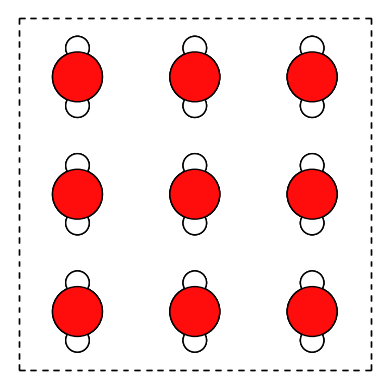

In [5]:
fig, ax = plt.subplots()
plot_atoms(water_molecules, ax)
ax.set_axis_off()

Contraining internel degrees of freedom. Constrain interatomic distances, O-H1, O-H2 and H1-H2 for each molecule.

In [6]:
water_molecules.constraints = FixBondLengths(
    [(3 * i + j, 3 * i + (j + 1) % 3) for i in range(3**3) for j in [0, 1, 2]]
)
# RATTLE-type constraints on O-H1, O-H2, H1-H2.
tag = 'tip3p_27mol_equil'
water_molecules.calc = TIP3P(rc=4.5)  # set the calculator to be the TIP3P force field

Equilibrate smaller box of water

In [5]:
# Equillibrate in a small box first.
md = Langevin(
    water_molecules,
    1 * units.fs,
    temperature_K=293.15,  # 20 °C
    friction=0.01,
    logfile=tag + '.log',
)

traj = Trajectory(tag + '.traj', 'w', water_molecules)
md.attach(traj.write, interval=1)
md.run(4)  # please use 4000 to better equilibrate

# Repeat box and equilibrate further.
tag = 'tip3p_216mol_equil'
water_molecules.set_constraint()  # repeat not compatible with FixBondLengths currently.
water_molecules *= (2, 2, 2)
water_molecules.constraints = FixBondLengths(
    [
        (3 * i + j, 3 * i + (j + 1) % 3)
        for i in range(len(water_molecules) // 3)
        for j in [0, 1, 2]
    ]
)
water_molecules.calc = TIP3P(rc=7.0)
md = Langevin(
    water_molecules,
    2 * units.fs,
    temperature_K=293.15,  # 20 °C
    friction=0.01,
    logfile=tag + '.log',
)

traj = Trajectory(tag + '.traj', 'w', water_molecules)
md.attach(traj.write, interval=1)
md.run(2)  # please use 2000 to better equilibrate

/home/fh22600/miniforge3/envs/testing/lib/python3.14/site-packages/ase/md/langevin.py:110: FutureWarning: The implementation of `fixcm=True` in `Langevin` does not strictly sample the correct NVT distributions. The deviations are typically small for large systems but can be more pronounced for small systems. Use `fixcm=False` together with `ase.constraints.FixCom`. `fixcm` is deprecated since ASE 3.28.0 and will be removed in a future release.
  warnings.warn(msg, FutureWarning)


True

 Visualise equilibration trajectories
 

In [6]:
from ase.io import read
from ase.visualize import view

In [7]:
water_uneq = read('tip3p_27mol_equil.traj')
view(water_uneq)

<Popen: returncode: None args: ['/home/fh22600/miniforge3/envs/testing/bin/p...>

In [8]:
water_eq = read('tip3p_216mol_equil.traj')
view(water_eq)

<Popen: returncode: None args: ['/home/fh22600/miniforge3/envs/testing/bin/p...>

## Perform basic MD simulations using ASE.

In [9]:
import matplotlib.pyplot as plt
import numpy as np

# choose one of the following implementations of EMT:
# included in ase
# from ase.calculators.emt import EMT
# faster performance
from asap3 import EMT
from ase.calculators.tip4p import TIP3P
from ase import units
from ase.cluster.cubic import FaceCenteredCubic as ClusterFCC
from ase.io.trajectory import Trajectory
from ase.lattice.cubic import FaceCenteredCubic as LatticeFCC
from ase.md.langevin import Langevin  # for later NPT simulations
from ase.md.velocitydistribution import (
    MaxwellBoltzmannDistribution,
    Stationary,
    ZeroRotation,
)
from ase.md.verlet import VelocityVerlet
from ase.optimize import QuasiNewton
from ase.visualize.plot import plot_atoms



1. Visualise initial structure

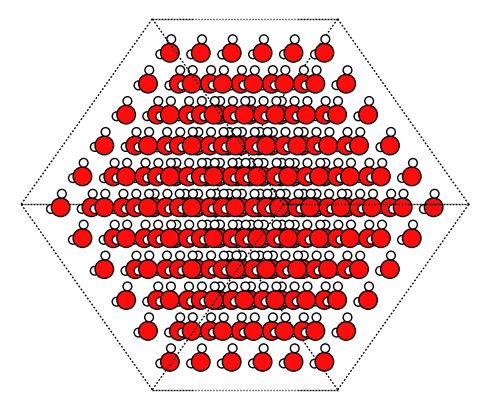

In [10]:
# visualise the initial structure
fig, ax = plt.subplots(figsize=(5,5))
plot_atoms(water_molecules, ax, rotation=('45x,45y,0z'))
ax.set_axis_off()
plt.tight_layout()
plt.show()

2. Run MD and monitor kinetic and potential energy of the whole system.

running a NVE simulation of equilibrated water 
Energy per atom: Epot =40.449eV  Ekin = 16.988eV (T=304.232K) Etot = 57.437eV
Energy per atom: Epot =40.213eV  Ekin = 17.225eV (T=308.464K) Etot = 57.438eV
Energy per atom: Epot =39.462eV  Ekin = 17.978eV (T=321.950K) Etot = 57.440eV
Energy per atom: Epot =38.053eV  Ekin = 19.390eV (T=347.233K) Etot = 57.443eV
Energy per atom: Epot =35.755eV  Ekin = 21.691eV (T=388.452K) Etot = 57.446eV
Energy per atom: Epot =32.273eV  Ekin = 25.175eV (T=450.838K) Etot = 57.448eV
Energy per atom: Epot =27.319eV  Ekin = 30.128eV (T=539.547K) Etot = 57.448eV
Energy per atom: Epot =20.719eV  Ekin = 36.722eV (T=657.618K) Etot = 57.441eV
Energy per atom: Epot =12.559eV  Ekin = 44.867eV (T=803.490K) Etot = 57.426eV
Energy per atom: Epot = 3.280eV  Ekin = 54.123eV (T=969.253K) Etot = 57.404eV
Energy per atom: Epot =-6.331eV  Ekin = 63.708eV (T=1140.900K) Etot = 57.377eV
Energy per atom: Epot =-15.301eV  Ekin = 72.654eV (T=1301.096K) Etot = 57.353eV
Energy per at

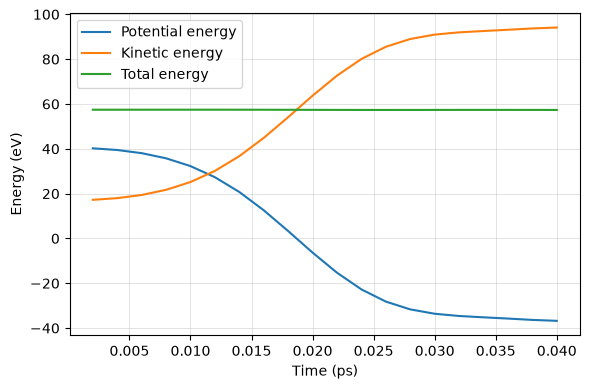

In [11]:
# Describe the interatomic interactions with the Effective Medium Theory (EMT)
water_molecules.calc = TIP3P()

# Set the initial velocities corresponding to T=300K from Maxwell Boltzmann
# Distribution
MaxwellBoltzmannDistribution(water_molecules, temperature_K=300)


timestep_fs = 1
dyn = VelocityVerlet(water_molecules, timestep_fs * units.fs)  # 1 fs time step.

def printenergy(a):
    """
    Function to print the thermodynamical properties i.e potential energy,
    kinetic energy and total energy
    """
    epot = a.get_potential_energy()
    ekin = a.get_kinetic_energy()
    temp = a.get_temperature()
    print(
        f'Energy per atom: Epot ={epot:6.3f}eV  Ekin = {ekin:.3f}eV '
        f'(T={temp:.3f}K) Etot = {epot + ekin:.3f}eV'
    )

# Now run the dynamics
print('running a NVE simulation of equilibrated water ')
printenergy(water_molecules)
# init lists to for energy vs time data
time_ps, epot, ekin = [], [], []
mdind = 0
steps_per_block = 2
for i in range(20):
    dyn.run(steps_per_block)
    mdind += steps_per_block
    printenergy(water_molecules)
    # save the energies of the current MD step
    time_ps.append(mdind * timestep_fs / 1000.0)
    epot.append(water_molecules.get_potential_energy())
    ekin.append(water_molecules.get_kinetic_energy())

etot = np.array(epot) + np.array(ekin)

# Plot energies vs time
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(time_ps, epot, label='Potential energy')
ax.plot(time_ps, ekin, label='Kinetic energy')
ax.plot(time_ps, etot, label='Total energy')
ax.set_xlabel('Time (ps)')
ax.set_ylabel('Energy (eV)')
ax.legend(loc='best')
ax.grid(True, linewidth=0.5, alpha=0.5)
plt.tight_layout()
plt.show()


## Physical scanning of 2 water molecules

In [15]:
from ase.calculators.lj import LennardJones
from ase import Atoms

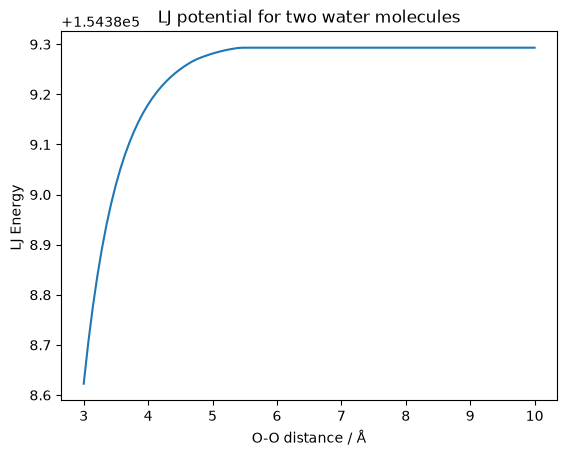

In [16]:
sigma = 3.15
epsilon = 0.65

distances = np.linspace(3, 10, 100)  
energies = []

for d in distances:
    atoms = Atoms('OHHOHH',
                positions=[
    [0., 0., 0.],   # oxygen 1
    [-1, 1, 0.],   # hydrogen 
    [-1, -1, 0.],   # hydrogen 
    [d  , 0 + d, 0 + d],   # oxygen 2
    [d-1, 1 + d, 0 + d],  # hydrogen
    [d+1,-1 + d, 0 + d],   # hydrogen
], pbc=False)
    
    atoms.calc = LennardJones(sigma=sigma, epsilon=epsilon)
    energies.append(atoms.get_potential_energy())

plt.plot(distances, energies)
plt.title('LJ potential for two water molecules')
plt.xlabel('O-O distance / Å')
plt.ylabel('LJ Energy ')
plt.show()

In [17]:
distances = np.linspace(2.5, 10, 3)
distances

array([ 2.5 ,  6.25, 10.  ])

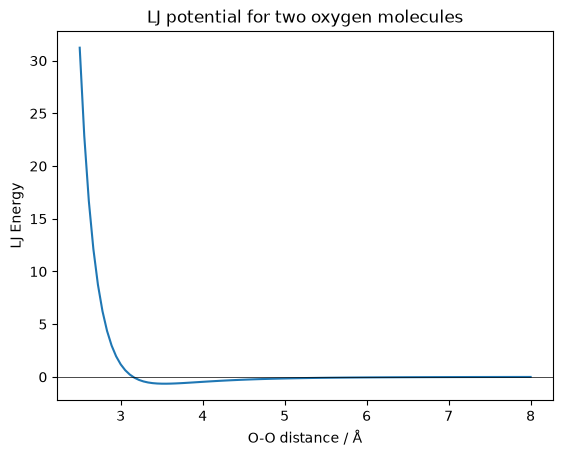

In [ ]:
from ase import Atoms
from ase.calculators.lj import LennardJones
import numpy as np
import matplotlib.pyplot as plt

# lj parameters for water 
sigma = 3.15  
epsilon = 0.65 

distances = np.linspace(2.5, 8.0, 100)
energies = []

for d in distances:
    atoms = Atoms(
        'OO',
        positions=[[0., 0., 0.],
                   [0., 0., d]]
    )
    atoms.calc = LennardJones(sigma=sigma, epsilon=epsilon)
    energies.append(atoms.get_potential_energy())

plt.figure()
plt.plot(distances, energies)
plt.axhline(0, color='k', linewidth=0.5)
plt.xlabel('O-O distance / Å')
plt.ylabel('LJ Energy')
plt.title('LJ potential for two oxygen molecules')

plt.show()

/home/fh22600/miniforge3/envs/testing/lib/python3.14/site-packages/ase/calculators/lj.py:213: RuntimeWarning: divide by zero encountered in divide
  c6 = (sigma ** 2 / r2) ** 3
/home/fh22600/miniforge3/envs/testing/lib/python3.14/site-packages/ase/calculators/lj.py:221: RuntimeWarning: invalid value encountered in subtract
  pairwise_energies = 4 * epsilon * (c12 - c6)
/home/fh22600/miniforge3/envs/testing/lib/python3.14/site-packages/ase/calculators/lj.py:222: RuntimeWarning: invalid value encountered in subtract
  pairwise_forces = -24 * epsilon * (2 * c12 - c6) / r2  # du_ij


Text(0.5, 1.0, 'LJ Potential between two waters')

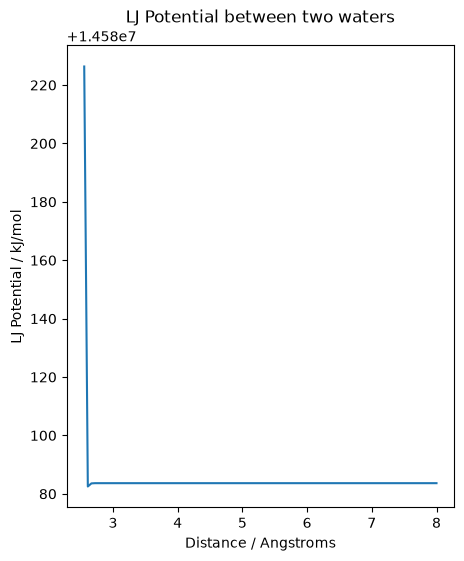

In [19]:
# lj parameters for water 
sigma = 3.15  
epsilon = 0.65 


h2o_1 = molecule('H2O')
h2o_2 = molecule('H2O')

distances = np.linspace(2.5, 8.0, 100)
energies = []
for d in distances:
    system = h2o_1 + h2o_2 
    h2o_2.translate([d, 0.0, 0.0])

    system.calc = LennardJones(sigma=sigma, epsilon=epsilon)
    energies.append(system.get_potential_energy())

fig, ax = plt.subplots(figsize=(5,6))
ax.plot(distances, energies)
ax.set_xlabel('Distance / Angstroms')
ax.set_ylabel('LJ Potential / kJ/mol')
ax.set_title('LJ Potential between two waters')


### Testing for translational invariance

Same energies when the box is translated

In [11]:
from ase import Atoms
from ase.calculators.lj import LennardJones
from ase.calculators.emt import EMT
import numpy as np
import matplotlib.pyplot as plt
# create system

system = Atoms('N2', 
               positions =[[0,0,-1],[0,0,1]], pbc=False)

# visualises system
# view(system)

# create calculator 
calc = EMT()
system.calc = calc

# defining step and timesteps 
step = 0.1
nsteps = int(6/step)

# writing positions to a trajectory file 
with Trajectory('binding_curve.traj', 'w') as traj:
    for i in range(nsteps):
        d = 0.5 + i * step

        # get systems energy
        system.positions[1, 2] = system.positions[0, 2] + d

        e = system.get_potential_energy()

        f = system.get_forces()

        print('distance, energy', d, e)
        print('force', f)

        # write to traj file 
        traj.write(system)


# use 'ase gui bidning_curve.traj' in terminal to play dissociation



distance, energy 0.5 9.870758556485448
force [[  0.           0.         -52.28823918]
 [  0.           0.          52.28823918]]
distance, energy 0.6 5.5891182020987875
force [[  0.           0.         -34.25676672]
 [  0.           0.          34.25676672]]
distance, energy 0.7 2.8596713200020494
force [[  0.           0.         -21.02820162]
 [  0.           0.          21.02820162]]
distance, energy 0.8 1.2619022218412255
force [[  0.           0.         -11.45544942]
 [  0.           0.          11.45544942]]
distance, energy 0.9 0.47657850003904656
force [[ 0.          0.         -4.64947593]
 [ 0.          0.          4.64947593]]
distance, energy 1.0 0.262852687667797
force [[ 0.          0.          0.07663707]
 [ 0.          0.         -0.07663707]]
distance, energy 1.1 0.440343573035614
force [[ 0.          0.          3.25179997]
 [ 0.          0.         -3.25179997]]
distance, energy 1.2000000000000002 0.8751414634853774
force [[ 0.        0.        5.281651]
 [ 0.    

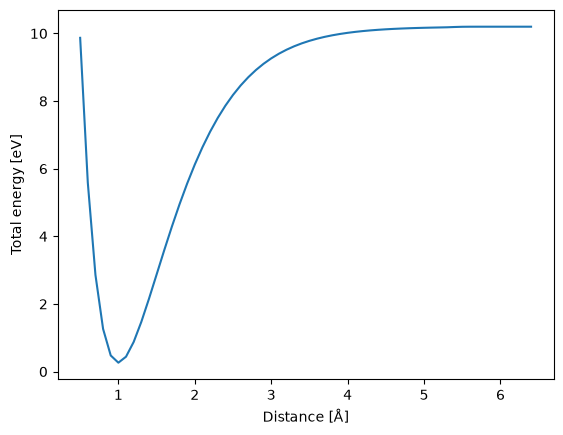

Dissociation energy [eV]:  9.937147312332202


In [12]:
import matplotlib.pyplot as plt
from ase.io import iread

energies = []
distances = []

for atoms in iread('binding_curve.traj'):
    energies.append(atoms.get_potential_energy())
    distances.append(atoms.positions[1, 2] - atoms.positions[0, 2])

ax = plt.gca()
ax.plot(distances, energies)
ax.set_xlabel('Distance [Å]')
ax.set_ylabel('Total energy [eV]')
plt.show()

print('Dissociation energy [eV]: ', energies[-1] - min(energies))

### Testing for translational invariance

In [20]:
og_pos = [[0, 0, -1],[0, 0, 1]] # calc is EMT from above 

# original position 
system.positions = og_pos

e = system.get_potential_energy()
print(f'Original Energy / eV : {e}')
print(f'Original positions : {system.positions}')

translation = np.array([4, 6, -4])
system.positions = og_pos + translation 

new_e = system.get_potential_energy()
print(f'New energy after translation / eV: {new_e}')
print(f'New positions : {system.positions}')



Original Energy / eV : 6.1239042559302534
Original positions : [[ 0.  0. -1.]
 [ 0.  0.  1.]]
New energy after translation / eV: 6.1239042559302534
New positions : [[ 4.  6. -5.]
 [ 4.  6. -3.]]


In [29]:
# more advanced 

# get original positions 
# generate random transformations 
# apply x amount of times 
# calculate energies and append them to a list/array 
energies = [3, 3, 3, 3,4]
# check if they are all the same 

e_array = np.array(energies)
np.unique(e_array, return_counts=True)

(array([3, 4]), array([4, 1]))

### Testing for rotational equivariance

Same forces when the box is rotated.

1. Calculate forces of system before rotation.
2. Obtain transformation applied to box.
3. Rotate the box and use forcefield to calculate energies and forces.
4. Apply inverse of rotation to force matrix, should give the original force matrix.

Create and equilibrate water box

/home/fh22600/miniforge3/envs/testing/lib/python3.14/site-packages/ase/md/langevin.py:110: FutureWarning: The implementation of `fixcm=True` in `Langevin` does not strictly sample the correct NVT distributions. The deviations are typically small for large systems but can be more pronounced for small systems. Use `fixcm=False` together with `ase.constraints.FixCom`. `fixcm` is deprecated since ASE 3.28.0 and will be removed in a future release.
  warnings.warn(msg, FutureWarning)


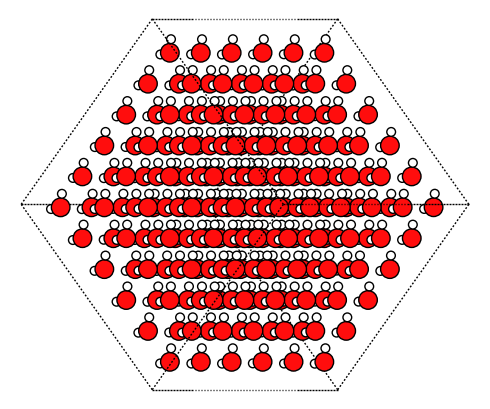

In [ ]:
water_molecules = molecule('H2O') # creating water molecule
density = 0.9982  # denisty of water in g/cm^3 at 20°C
box_length = ((water_molecules.get_masses().sum() / units.mol) / (density * 1e-24)) ** (
    1 / 3
)  # box length in Å
water_molecules.set_cell((box_length, box_length, box_length))
water_molecules.center()
# Repeat the water molecule we just created to end up with a PBC cell
water_molecules *= (3, 3, 3)
water_molecules.set_pbc(True)

water_molecules.constraints = FixBondLengths(
    [(3 * i + j, 3 * i + (j + 1) % 3) for i in range(3**3) for j in [0, 1, 2]]
)
# RATTLE-type constraints on O-H1, O-H2, H1-H2.
tag = 'tip3p_27mol_equil'
water_molecules.calc = TIP3P(rc=4.5)  # set the calculator to be the TIP3P force field

# Equillibrate in a small box first.
md = Langevin(
    water_molecules,
    1 * units.fs,
    temperature_K=293.15,  # 20 °C
    friction=0.01,
    logfile=tag + '.log',
)

traj = Trajectory(tag + '.traj', 'w', water_molecules)
md.attach(traj.write, interval=1)
md.run(4)  # please use 4000 to better equilibrate

# Repeat box and equilibrate further.
tag = 'tip3p_216mol_equil'
water_molecules.set_constraint()  # repeat not compatible with FixBondLengths currently.
water_molecules *= (2, 2, 2)
water_molecules.constraints = FixBondLengths(
    [
        (3 * i + j, 3 * i + (j + 1) % 3)
        for i in range(len(water_molecules) // 3)
        for j in [0, 1, 2]
    ]
)
water_molecules.calc = TIP3P(rc=7.0)
md = Langevin(
    water_molecules,
    2 * units.fs,
    temperature_K=293.15,  # 20 °C
    friction=0.01,
    logfile=tag + '.log',
)

traj = Trajectory(tag + '.traj', 'w', water_molecules)
md.attach(traj.write, interval=1)
md.run(2)  # please use 2000 to better equilibrate


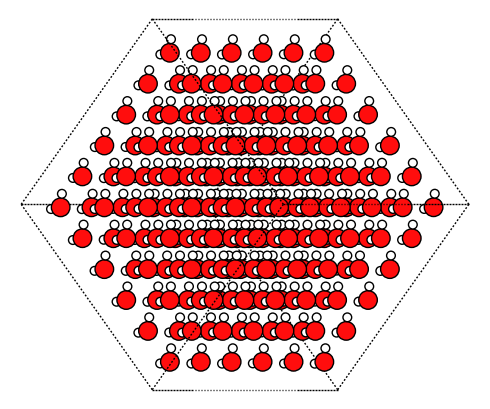

In [4]:
# visualise water box 
fig, ax = plt.subplots(figsize=(5,5))
plot_atoms(water_molecules, ax, rotation=('45x,45y,0z'))
ax.set_axis_off()
plt.tight_layout()
plt.show()

In [6]:
len(water_molecules)

648

Test for energy conservation and rotational equivariance on water box

In [23]:
import numpy as np
from scipy.spatial.transform import Rotation as R

# calculate og energy and forces 

og_energy = water_molecules.get_potential_energy()
og_forces = water_molecules.get_forces()

# generate random rotation matrix 
rotation_matrix = R.random(random_state=42).as_matrix()

# create copy of water box 
new_water = water_molecules.copy()

# rotate water positions 
new_water.positions = new_water.positions @ rotation_matrix  

new_water.calc = water_molecules.calc

# calculate energy of forces of rotated water 
new_energy = new_water.get_potential_energy()
new_forces = new_water.get_forces()

# rotate original forces by same matrix to compare
#og_forces_rotated = og_forces @ rotation_matrix

# multiply rotated forces by inv of rotation matrix 

inv_rotation = new_forces @ np.linalg.inv(rotation_matrix)


print(f'Energy original:  {og_energy:.6f}')
print(f'Energy rotated:   {new_energy:.6f}')
print(f'Energy invariant: {np.isclose(og_energy, new_energy)}')


print(f'Forces invariant: {np.allclose(og_forces, inv_rotation, atol=1e-6)}')
print(f'Max force diff:   {np.max(np.abs(og_forces - inv_rotation)):.2e}')

Energy original:  35.516860
Energy rotated:   12370.994852
Energy invariant: False
Forces invariant: False
Max force diff:   4.38e+03


Testing for energy conservation and rotational equivariance on two water molecules

In [25]:
import numpy as np
from scipy.spatial.transform import Rotation as R
from ase import Atoms
from ase.calculators.lj import LennardJones

# 2 waters with no box 
atoms = Atoms('OHHOHH',
              positions=[
                  [0.,    0.,    0.  ],
                  [-0.757,-0.586, 0. ],
                  [0.757, -0.586, 0. ],
                  [4.,    0.,    0.  ],
                  [3.243,-0.586, 0.  ],
                  [4.757,-0.586, 0.  ],
              ],
              pbc=False) 

atoms.calc = LennardJones()
og_energy = atoms.get_potential_energy()
og_forces = atoms.get_forces()

# rotation matrix 
rotation_matrix = R.random(random_state=42).as_matrix()
atoms_rot = atoms.copy()
atoms_rot.positions = atoms_rot.positions @ rotation_matrix
atoms_rot.calc = LennardJones()

# get energy and forces of rotated 
new_energy = atoms_rot.get_potential_energy()
new_forces = atoms_rot.get_forces() 

og_forces_rotated = og_forces @ rotation_matrix

print(f'Energy original:  {og_energy:.6f}')
print(f'Energy rotated:   {new_energy:.6f}')
print(f'Energy invariant: {np.isclose(og_energy, new_energy)}')
print(f'Forces invariant: {np.allclose(og_forces_rotated, new_forces, atol=1e-6)}')

Energy original:  5.632277
Energy rotated:   5.632277
Energy invariant: True
Forces invariant: True
